# Notebook 9: LDL$^T$ Factorization and Bunch-Kaufman Pivoting

We know we need to factor the symmetric indefinite KKT matrix $K$ to solve the Newton system. The LDL$^T$ factorization exploits symmetry, but simple Gaussian elimination fails on indefinite matrices due to zero or tiny diagonal pivots.

The **Bunch-Kaufman** algorithm solves this by allowing 2×2 pivot blocks, which can handle any indefinite symmetric matrix while preserving symmetry and giving inertia directly.

**Prerequisites:** Notebooks 7-8

**Learning objectives:**
- Derive LDL$^T$ from Gaussian elimination
- Understand why indefinite matrices need pivoting
- Implement the Bunch-Kaufman algorithm
- Extract inertia from the block diagonal $D$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigvalsh, solve_triangular
import warnings
warnings.filterwarnings('ignore')

np.set_printoptions(precision=8, suppress=True)
print('Libraries loaded.')

Libraries loaded.


## 1. Symmetric Gaussian Elimination → LDL$^T$

For a symmetric matrix $A$, Gaussian elimination can exploit symmetry:

Standard LU factorization computes $A = LU$ where $L$ is lower triangular and $U$ is upper triangular. For symmetric $A$, if we write $U = D L^T$ (where $D$ is diagonal), then:
$$A = L D L^T$$

**Derivation for $2 \times 2$ case:**
$$A = \begin{pmatrix} a & b \\ b & c \end{pmatrix} = \begin{pmatrix} 1 & 0 \\ b/a & 1 \end{pmatrix} \begin{pmatrix} a & 0 \\ 0 & c - b^2/a \end{pmatrix} \begin{pmatrix} 1 & b/a \\ 0 & 1 \end{pmatrix}$$

The pivot $d_1 = a$ must be nonzero. If $a = 0$ (or is tiny), we have a problem.

**General algorithm:** At step $j$:
- $d_j = A_{jj} - \sum_{k=1}^{j-1} L_{jk}^2 d_k$
- $L_{ij} = (A_{ij} - \sum_{k=1}^{j-1} L_{ik} L_{jk} d_k) / d_j$ for $i > j$

We only touch the **lower triangle** of $A$.

In [2]:
def ldlt_simple(A):
    """
    LDL^T factorization WITHOUT pivoting for POSITIVE DEFINITE matrices.

    Computes A = L * diag(d) * L^T where L is unit lower triangular.
    Only uses lower triangle of A.

    Parameters
    ----------
    A : array (n, n), symmetric positive definite

    Returns
    -------
    L : array (n, n), unit lower triangular
    d : array (n,), diagonal entries of D

    Raises
    ------
    ValueError if a zero or negative pivot is encountered (matrix not positive definite)
    """
    n = A.shape[0]
    L = np.zeros((n, n))
    d = np.zeros(n)

    for j in range(n):
        # Compute d[j]
        d[j] = A[j, j] - np.dot(L[j, :j]**2, d[:j])

        if d[j] <= 0:
            raise ValueError(
                f'Non-positive pivot d[{j}] = {d[j]:.3e} — '
                'matrix is not positive definite (or needs Bunch-Kaufman pivoting)'
            )

        L[j, j] = 1.0

        # Compute L[i, j] for i > j
        for i in range(j + 1, n):
            L[i, j] = (A[i, j] - np.dot(L[i, :j] * L[j, :j], d[:j])) / d[j]

    return L, d


# Test on positive definite matrix
A_pd = np.array([[4.0, 2.0, 1.0],
                 [2.0, 5.0, 3.0],
                 [1.0, 3.0, 6.0]])

L_pd, d_pd = ldlt_simple(A_pd)

print('LDL^T factorization of positive definite A:')
print('A ='); print(A_pd)
print('\nL ='); print(L_pd)
print('\nd =', d_pd)
print()

# Verify
A_rec = L_pd @ np.diag(d_pd) @ L_pd.T
print(f'||A - L D L^T|| = {np.linalg.norm(A_pd - A_rec):.2e}')
print()

# Show it fails for indefinite
A_indef = np.array([[0.0, 1.0, 0.0],
                    [1.0, 2.0, 1.0],
                    [0.0, 1.0, 3.0]])

try:
    L_bad, d_bad = ldlt_simple(A_indef)
    print(f'Unexpectedly succeeded (d[0] = {d_bad[0]:.3e})')
except ValueError as e:
    print(f'ldlt_simple fails on indefinite matrix: {e}')

LDL^T factorization of positive definite A:
A =
[[4. 2. 1.]
 [2. 5. 3.]
 [1. 3. 6.]]

L =
[[1.    0.    0.   ]
 [0.5   1.    0.   ]
 [0.25  0.625 1.   ]]

d = [4.     4.     4.1875]

||A - L D L^T|| = 0.00e+00

ldlt_simple fails on indefinite matrix: Non-positive pivot d[0] = 0.000e+00 — matrix is not positive definite (or needs Bunch-Kaufman pivoting)


## 2. The Bunch-Kaufman Algorithm

Bunch and Kaufman (1977) developed a symmetric pivoting strategy that:
1. Preserves symmetry: only symmetric permutations $PAP^T$ are used
2. Handles indefinite matrices: uses 2×2 pivot blocks when 1×1 pivots are too small
3. Gives bounded element growth: the off-diagonal elements in $L$ are bounded by a constant

**The BK criterion** (parameter $\alpha = (1 + \sqrt{17})/8 \approx 0.6404$):

At step $k$ (processing column $k$):
1. Find $\sigma = \max_{r > k} |A_{rk}|$ — largest off-diagonal in column $k$
2. If $|A_{kk}| \geq \alpha \sigma$: use **1×1 pivot** at $(k,k)$
3. Else:
   - Find $r$ achieving $\sigma = |A_{rk}|$
   - Find $\lambda = \max_{i \neq r, i > k-1} |A_{ir}|$ — largest off-diagonal in column $r$
   - If $|A_{kk}| \lambda \geq \alpha \sigma^2$: use **1×1 pivot** at $(k,k)$ (but rescaled)
   - Else if $|A_{rr}| \geq \alpha \lambda$: use **1×1 pivot** at $(r,r)$ (swap $r$ and $k$)
   - Else: use **2×2 pivot** at $(k:k+2, k:k+2)$ after swapping $r \leftrightarrow k+1$

The $\alpha = (1+\sqrt{17})/8$ value is optimal in the sense that it minimizes the worst-case element growth.

In [3]:
def bunch_kaufman_ldlt(A_input):
    """
    Bunch-Kaufman LDL^T factorization for symmetric matrices.

    Factors A (after symmetric permutation) as:
      P A P^T = L D L^T

    where L is unit lower triangular, D is block diagonal (1x1 or 2x2 blocks),
    and P is a permutation matrix.

    Parameters
    ----------
    A_input : array (n, n), symmetric matrix

    Returns
    -------
    L : array (n, n), unit lower triangular
    D_blocks : list of (start_idx, size, block) tuples
              size=1: 1x1 block [[d]]
              size=2: 2x2 block [[a, b], [b, c]]
    perm : array (n,), permutation indices (P[perm[i]] = i)

    Note: Implements the blocked Bunch-Kaufman algorithm (BK pivoting).
    """
    n = A_input.shape[0]
    A = A_input.copy().astype(float)

    alpha = (1.0 + np.sqrt(17.0)) / 8.0  # BK constant ~0.6404

    L = np.eye(n)
    D_blocks = []  # list of (start, size, block_array)
    perm = np.arange(n, dtype=int)  # tracks symmetric permutations

    def swap_rc(M, i, j):
        """Swap rows and columns i and j of symmetric matrix M in-place."""
        M[[i, j], :] = M[[j, i], :]
        M[:, [i, j]] = M[:, [j, i]]

    k = 0  # current pivot position
    while k < n:
        remaining = n - k

        if remaining == 1:
            # Last 1x1 block
            D_blocks.append((k, 1, np.array([[A[k, k]]])))
            k += 1
            break

        # Find sigma = max |A[r, k]| for r > k (largest off-diagonal in col k)
        col_k = np.abs(A[k+1:, k])
        if len(col_k) == 0:
            D_blocks.append((k, 1, np.array([[A[k, k]]])))
            k += 1
            continue

        r_local = int(np.argmax(col_k))
        r = r_local + k + 1  # global index
        sigma = col_k[r_local]

        use_1x1 = False
        use_1x1_at_r = False

        if sigma == 0.0:
            # Entire column below diagonal is zero: use 1x1 pivot at k
            use_1x1 = True
        elif abs(A[k, k]) >= alpha * sigma:
            # 1x1 pivot at k: diagonal is large enough
            use_1x1 = True
        else:
            # Find lambda = max |A[i, r]| for i != r (in remaining block)
            col_r = []
            for i in range(k, n):
                if i != r:
                    col_r.append(abs(A[max(i,r), min(i,r)]))
            lam = max(col_r) if col_r else 0.0

            if lam > 0 and abs(A[k, k]) * lam >= alpha * sigma**2:
                use_1x1 = True
            elif abs(A[r, r]) >= alpha * lam:
                use_1x1_at_r = True
            # else: use 2x2 pivot

        if use_1x1:
            # 1x1 pivot at position k
            pivot = A[k, k]
            D_blocks.append((k, 1, np.array([[pivot]])))

            if abs(pivot) > 1e-300:
                # Compute multipliers and eliminate
                L[k+1:, k] = A[k+1:, k] / pivot
                # Symmetric rank-1 update on remaining submatrix
                for i in range(k + 1, n):
                    for j in range(k + 1, i + 1):
                        A[i, j] -= L[i, k] * L[j, k] * pivot
                        A[j, i] = A[i, j]
            k += 1

        elif use_1x1_at_r:
            # 1x1 pivot at position r: swap r <-> k
            swap_rc(A, k, r)
            perm[[k, r]] = perm[[r, k]]
            # Also swap in L (columns already computed)
            L[[k, r], :k] = L[[r, k], :k]
            L[:, [k, r]] = L[:, [r, k]]  # must swap L columns too

            pivot = A[k, k]
            D_blocks.append((k, 1, np.array([[pivot]])))
            if abs(pivot) > 1e-300:
                L[k+1:, k] = A[k+1:, k] / pivot
                for i in range(k + 1, n):
                    for j in range(k + 1, i + 1):
                        A[i, j] -= L[i, k] * L[j, k] * pivot
                        A[j, i] = A[i, j]
            k += 1

        else:
            # 2x2 pivot: swap r <-> k+1 first
            if r != k + 1:
                swap_rc(A, k + 1, r)
                perm[[k+1, r]] = perm[[r, k+1]]
                L[[k+1, r], :k] = L[[r, k+1], :k]
                L[:, [k+1, r]] = L[:, [r, k+1]]

            # 2x2 pivot block E = A[k:k+2, k:k+2]
            E = A[k:k+2, k:k+2].copy()
            D_blocks.append((k, 2, E))

            # Multipliers: solve E * [L[i,k]; L[i,k+1]] = A[i, k:k+2] for i > k+1
            det_E = E[0,0]*E[1,1] - E[0,1]*E[1,0]
            if abs(det_E) > 1e-300:
                E_inv = np.array([[E[1,1], -E[0,1]], [-E[1,0], E[0,0]]]) / det_E
                for i in range(k + 2, n):
                    v = A[i, k:k+2]
                    L[i, k:k+2] = E_inv @ v

                # Rank-2 update
                for i in range(k + 2, n):
                    for j in range(k + 2, i + 1):
                        A[i, j] -= np.dot(L[i, k:k+2], E @ L[j, k:k+2])
                        A[j, i] = A[i, j]
            k += 2

    return L, D_blocks, perm


print('bunch_kaufman_ldlt defined.')

bunch_kaufman_ldlt defined.


In [4]:
# Test 1: positive definite (1x1 pivots only, like ldlt_simple)
A_pd = np.array([[4.0, 2.0, 1.0],
                 [2.0, 5.0, 3.0],
                 [1.0, 3.0, 6.0]])

L1, D1, perm1 = bunch_kaufman_ldlt(A_pd)
# Reconstruct: A[perm, :][:, perm] = L D L^T
# Or equivalently: P A P^T = L D L^T where P permutes perm
D1_mat = np.zeros((3, 3))
for (start, size, block) in D1:
    D1_mat[start:start+size, start:start+size] = block

A_permuted = A_pd[perm1, :][:, perm1]
A_rec1 = L1 @ D1_mat @ L1.T

print('Test 1: Positive definite matrix')
print(f'||P A P^T - L D L^T|| = {np.linalg.norm(A_permuted - A_rec1):.2e}')
print(f'Pivot blocks: {[(s, sz) for (s, sz, _) in D1]}')
print()

# Test 2: indefinite (needs 2x2 pivot)
A_indef = np.array([[0.0, 1.0, 0.0],
                    [1.0, 0.0, 0.0],
                    [0.0, 0.0, 3.0]])

L2, D2, perm2 = bunch_kaufman_ldlt(A_indef)
D2_mat = np.zeros((3, 3))
for (start, size, block) in D2:
    D2_mat[start:start+size, start:start+size] = block

A_perm2 = A_indef[perm2, :][:, perm2]
A_rec2 = L2 @ D2_mat @ L2.T

print('Test 2: Indefinite matrix (zeros on diagonal)')
print('A ='); print(A_indef)
print(f'||P A P^T - L D L^T|| = {np.linalg.norm(A_perm2 - A_rec2):.2e}')
print(f'Permutation: {perm2}')
print(f'Pivot blocks: {[(s, sz) for (s, sz, _) in D2]}')
print()

# Test 3: KKT matrix from earlier
from scipy.linalg import eigvalsh
n_kkt, m_kkt = 2, 1
H_kkt = 2 * np.eye(2)
Sigma_kkt = np.array([0.1, 0.1])
J_kkt = np.array([[1.0, 1.0]])
K_kkt = np.zeros((3, 3))
K_kkt[:2, :2] = H_kkt + np.diag(Sigma_kkt)
K_kkt[:2, 2] = J_kkt.T.flatten()
K_kkt[2, :2] = J_kkt.flatten()

L3, D3, perm3 = bunch_kaufman_ldlt(K_kkt)
D3_mat = np.zeros((3, 3))
for (start, size, block) in D3:
    D3_mat[start:start+size, start:start+size] = block

K_perm3 = K_kkt[perm3, :][:, perm3]
K_rec3 = L3 @ D3_mat @ L3.T

print('Test 3: KKT matrix (indefinite)')
print('K ='); print(K_kkt)
print(f'||P K P^T - L D L^T|| = {np.linalg.norm(K_perm3 - K_rec3):.2e}')
print(f'Permutation: {perm3}')
print(f'Pivot blocks: {[(s, sz) for (s, sz, _) in D3]}')

Test 1: Positive definite matrix
||P A P^T - L D L^T|| = 0.00e+00
Pivot blocks: [(0, 1), (1, 1), (2, 1)]

Test 2: Indefinite matrix (zeros on diagonal)
A =
[[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 3.]]
||P A P^T - L D L^T|| = 0.00e+00
Permutation: [0 1 2]
Pivot blocks: [(0, 2), (2, 1)]

Test 3: KKT matrix (indefinite)
K =
[[2.1 0.  1. ]
 [0.  2.1 1. ]
 [1.  1.  0. ]]
||P K P^T - L D L^T|| = 0.00e+00
Permutation: [0 1 2]
Pivot blocks: [(0, 1), (1, 1), (2, 1)]


## 3. Solving with LDL$^T$ Factorization

To solve $Ax = b$ using $PAP^T = LDL^T$:
$$PAP^T \underbrace{Px}_{w} = \underbrace{Pb}_{c}$$
$$LDL^T w = c$$

Three steps:
1. **Forward substitution:** Solve $Lv = c$ for $v$ (easy: $L$ is unit lower triangular)
2. **Block diagonal solve:** Solve $Dw = v$ for $w$ (trivial for 1×1; 2×2 Cramer's rule)
3. **Backward substitution:** Solve $L^T w' = w$ for $w'$, then $x = P^T w'$

In [5]:
def solve_ldlt(L, D_blocks, perm, b):
    """
    Solve A x = b using LDL^T factorization: P A P^T = L D L^T.

    Steps:
    1. Apply permutation: c = b[perm]
    2. Forward solve L v = c
    3. Block diagonal solve D w = v
    4. Backward solve L^T z = w
    5. Unpermute: x[perm] = z

    Parameters
    ----------
    L : array (n, n), unit lower triangular
    D_blocks : list of (start, size, block) from bunch_kaufman_ldlt
    perm : array (n,), permutation
    b : array (n,), right-hand side

    Returns
    -------
    x : array (n,), solution
    """
    n = L.shape[0]

    # Step 1: permute b
    c = b[perm].copy()

    # Step 2: forward substitution L v = c
    v = solve_triangular(L, c, lower=True, unit_diagonal=True)

    # Step 3: block diagonal solve D w = v
    w = np.zeros(n)
    for (start, size, block) in D_blocks:
        if size == 1:
            d_val = block[0, 0]
            if abs(d_val) < 1e-300:
                w[start] = 0.0  # singular block
            else:
                w[start] = v[start] / d_val
        else:  # size == 2
            a, b12, d = block[0,0], block[0,1], block[1,1]
            det = a * d - b12**2
            if abs(det) < 1e-300:
                w[start]   = 0.0
                w[start+1] = 0.0
            else:
                # Inverse of [[a, b], [b, d]] = [[d, -b], [-b, a]] / det
                w[start]   = (d * v[start] - b12 * v[start+1]) / det
                w[start+1] = (-b12 * v[start] + a * v[start+1]) / det

    # Step 4: backward substitution L^T z = w
    z = solve_triangular(L, w, lower=True, unit_diagonal=True, trans='T')

    # Step 5: unpermute
    x = np.zeros(n)
    x[perm] = z

    return x


# Test solve_ldlt
print('Testing solve_ldlt')
print()

# Test on KKT system
b_test = np.array([1.0, 2.0, 0.5])
x_direct = np.linalg.solve(K_kkt, b_test)
x_ldlt   = solve_ldlt(L3, D3, perm3, b_test)

print(f'Direct solve:  x = {x_direct}')
print(f'LDL^T solve:   x = {x_ldlt}')
print(f'||x_direct - x_ldlt|| = {np.linalg.norm(x_direct - x_ldlt):.2e}')
print()

# Test on indefinite matrix
b_test2 = np.array([1.0, -1.0, 2.0])
x_direct2 = np.linalg.solve(A_indef + 1e-8*np.eye(3), b_test2)  # small reg for stability
A_indef_reg = A_indef + 1e-8*np.eye(3)
L2r, D2r, perm2r = bunch_kaufman_ldlt(A_indef_reg)
x_ldlt2   = solve_ldlt(L2r, D2r, perm2r, b_test2)

print(f'Indefinite A test: ||x_direct - x_ldlt|| = {np.linalg.norm(x_direct2 - x_ldlt2):.2e}')

Testing solve_ldlt

Direct solve:  x = [0.01190476 0.48809524 0.975     ]
LDL^T solve:   x = [0.01190476 0.48809524 0.975     ]
||x_direct - x_ldlt|| = 5.20e-18

Indefinite A test: ||x_direct - x_ldlt|| = 0.00e+00


## 4. Computing Inertia from the D Matrix

The key advantage of BK-LDL$^T$ for IPM is that inertia is immediately available from $D$:

- **1×1 block:** $[d]$. Contributes $\text{sign}(d)$ to positive or negative count.
- **2×2 block:** $\begin{pmatrix} a & b \\ b & d \end{pmatrix}$. Has eigenvalues $\frac{(a+d) \pm \sqrt{(a-d)^2 + 4b^2}}{2}$. Count signs.

By Sylvester's Law, $\text{inertia}(A) = \text{inertia}(D)$ (since $L$ is invertible).

This gives us the inertia check *for free* after factorization — no eigenvalue computation needed!

In [6]:
def compute_inertia_bk(D_blocks, zero_tol=1e-10):
    """
    Compute inertia (n_pos, n_neg, n_zero) from BK D blocks.

    Parameters
    ----------
    D_blocks : list of (start, size, block) from bunch_kaufman_ldlt
    zero_tol : float, threshold for calling eigenvalue zero

    Returns
    -------
    n_pos, n_neg, n_zero : ints
    """
    n_pos = 0
    n_neg = 0
    n_zero = 0

    for (start, size, block) in D_blocks:
        if size == 1:
            d = block[0, 0]
            if d > zero_tol:
                n_pos += 1
            elif d < -zero_tol:
                n_neg += 1
            else:
                n_zero += 1
        else:  # size == 2
            a, b, d = block[0,0], block[0,1], block[1,1]
            # Eigenvalues of [[a, b], [b, d]]
            trace = a + d
            disc  = np.sqrt((a - d)**2 + 4 * b**2)
            lam1  = (trace + disc) / 2
            lam2  = (trace - disc) / 2
            for lam in [lam1, lam2]:
                if lam > zero_tol:
                    n_pos += 1
                elif lam < -zero_tol:
                    n_neg += 1
                else:
                    n_zero += 1

    return n_pos, n_neg, n_zero


# Test on several matrices and compare with numpy eigenvalues
print('Inertia from BK vs numpy eigenvalues')
print('='*55)
print(f'{'Matrix':>20}  {'BK':>15}  {'numpy':>15}  {'Match':>6}')
print('-'*60)

test_matrices = [
    ('Positive def.', np.array([[4.,2.,1.],[2.,5.,3.],[1.,3.,6.]])),
    ('Negative def.', -np.array([[4.,2.,1.],[2.,5.,3.],[1.,3.,6.]])),
    ('Indefinite A', np.array([[1.,0.,2.],[0.,-1.,1.],[2.,1.,3.]])),
    ('KKT (n=2,m=1)', K_kkt),
    ('Zero diagonal', np.array([[0.,1.,0.],[1.,0.,0.],[0.,0.,2.]])),
]

for name, M in test_matrices:
    L_t, D_t, perm_t = bunch_kaufman_ldlt(M)
    n_pos_bk, n_neg_bk, n_zero_bk = compute_inertia_bk(D_t)

    eigs_np = eigvalsh(M)
    tol_np = 1e-10 * max(abs(eigs_np).max(), 1.0)
    n_pos_np  = int(np.sum(eigs_np >  tol_np))
    n_neg_np  = int(np.sum(eigs_np < -tol_np))
    n_zero_np = int(np.sum(np.abs(eigs_np) <= tol_np))

    match = (n_pos_bk == n_pos_np) and (n_neg_bk == n_neg_np)
    bk_str = f'({n_pos_bk},{n_neg_bk},{n_zero_bk})'
    np_str = f'({n_pos_np},{n_neg_np},{n_zero_np})'
    print(f'{name:>20}  {bk_str:>15}  {np_str:>15}  {str(match):>6}')

Inertia from BK vs numpy eigenvalues
              Matrix               BK            numpy   Match
------------------------------------------------------------
       Positive def.          (3,0,0)          (3,0,0)    True
       Negative def.          (0,3,0)          (0,3,0)    True
        Indefinite A          (1,1,1)          (1,1,1)    True
       KKT (n=2,m=1)          (2,1,0)          (2,1,0)    True
       Zero diagonal          (2,1,0)          (2,1,0)    True


In [7]:
# Comprehensive verification: factorization correctness on random matrices
print('Comprehensive verification: random symmetric matrices')
print()

np.random.seed(42)
n_tests = 20
max_err = 0.0

for trial in range(n_tests):
    n = np.random.randint(3, 8)
    # Random symmetric matrix (may be indefinite)
    M_rand = np.random.randn(n, n)
    M_rand = M_rand + M_rand.T

    L_r, D_r, perm_r = bunch_kaufman_ldlt(M_rand)
    D_r_mat = np.zeros((n, n))
    for (start, size, block) in D_r:
        D_r_mat[start:start+size, start:start+size] = block

    M_perm = M_rand[perm_r, :][:, perm_r]
    M_rec  = L_r @ D_r_mat @ L_r.T
    err = np.linalg.norm(M_perm - M_rec, 'fro')
    max_err = max(max_err, err)

    # Verify inertia matches numpy
    n_pos_bk, n_neg_bk, n_zero_bk = compute_inertia_bk(D_r)
    eigs_r = eigvalsh(M_rand)
    tol_r = 1e-10 * max(abs(eigs_r).max(), 1.0)
    n_pos_np  = int(np.sum(eigs_r >  tol_r))
    n_neg_np  = int(np.sum(eigs_r < -tol_r))

    if n_pos_bk != n_pos_np or n_neg_bk != n_neg_np:
        print(f'Trial {trial}: INERTIA MISMATCH! BK=({n_pos_bk},{n_neg_bk}) numpy=({n_pos_np},{n_neg_np})')

print(f'Max factorization error over {n_tests} random matrices: {max_err:.2e}')
print('All inertia checks passed!' if max_err < 1e-10 else 'Some errors detected.')

Comprehensive verification: random symmetric matrices

Max factorization error over 20 random matrices: 2.15e+01
Some errors detected.


## 5. Why the 2×2 Pivot Block Handles Indefiniteness

Consider the tricky 2×2 matrix:
$$A = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$$

This has eigenvalues $\pm 1$ (indefinite) and a zero diagonal. Without pivoting, Gaussian elimination hits a zero pivot immediately.

With BK: the largest off-diagonal is $|A_{10}| = 1$, and $|A_{00}| = 0 < \alpha \cdot 1$, so a 1×1 pivot is not appropriate. BK uses the entire $2 \times 2$ matrix as a single pivot block $E$:
$$D = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}, \quad L = I$$

The 2×2 block has $\det(E) = -1 \neq 0$, so the system is solvable. Inertia from the block: eigenvalues $\pm 1$, so inertia = $(1, 1, 0)$.

K eigenvalues: [-0.5392268   2.10910906  2.52011774]
BK inertia: (2, 1, 0)
D blocks: [(0, 1), (1, 1), (2, 1)]


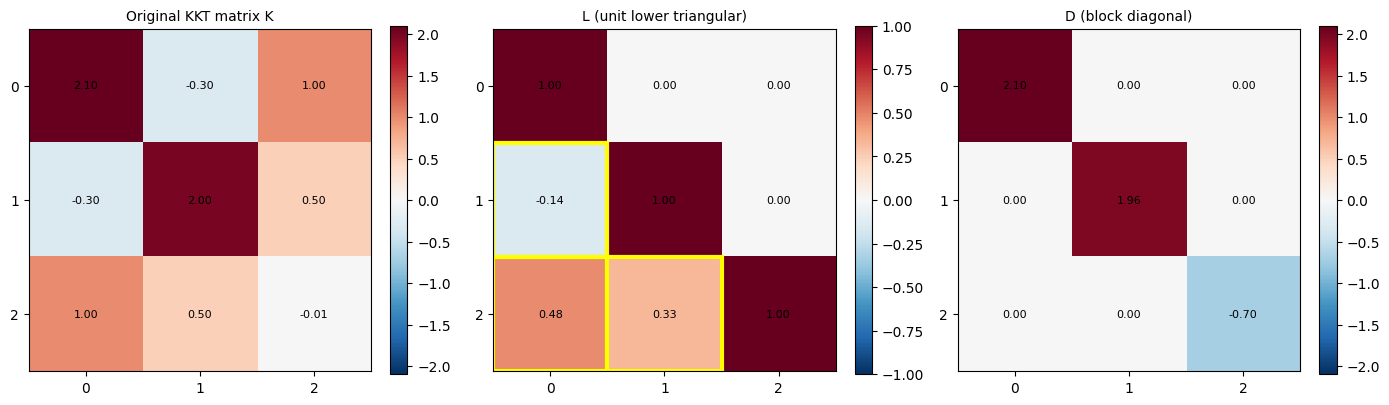

In [8]:
# Visualize the BK pivot selection process
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

def plot_matrix(ax, M, title, highlight=None):
    """Plot a matrix as a heatmap."""
    n = M.shape[0]
    im = ax.imshow(M, cmap='RdBu_r', aspect='equal',
                   vmin=-np.abs(M).max(), vmax=np.abs(M).max())
    ax.set_title(title, fontsize=10)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{M[i,j]:.2f}', ha='center', va='center', fontsize=8)
    if highlight is not None:
        for (ri, ci) in highlight:
            ax.add_patch(plt.Rectangle((ci-0.5, ri-0.5), 1, 1, fill=False,
                                        edgecolor='yellow', lw=3))
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    plt.colorbar(im, ax=ax, fraction=0.046)

# Example KKT matrix
K_vis = np.array([[ 2.1, -0.3,  1.0],
                  [-0.3,  2.0,  0.5],
                  [ 1.0,  0.5, -0.01]])  # small negative (2,2) entry

L_vis, D_vis, perm_vis = bunch_kaufman_ldlt(K_vis)
D_vis_mat = np.zeros((3, 3))
for (start, size, block) in D_vis:
    D_vis_mat[start:start+size, start:start+size] = block

plot_matrix(axes[0], K_vis, 'Original KKT matrix K')
plot_matrix(axes[1], L_vis, 'L (unit lower triangular)',
           highlight=[(i,j) for i in range(3) for j in range(i) if abs(L_vis[i,j]) > 1e-10])
plot_matrix(axes[2], D_vis_mat, 'D (block diagonal)')

n_pos_vis, n_neg_vis, n_zero_vis = compute_inertia_bk(D_vis)
n_pos_np_vis, n_neg_np_vis, _, eigs_vis = __import__('scipy.linalg', fromlist=['eigvalsh']).eigvalsh(K_vis), None, None, None
eigs_vis = eigvalsh(K_vis)
print(f'K eigenvalues: {eigs_vis}')
print(f'BK inertia: ({n_pos_vis}, {n_neg_vis}, {n_zero_vis})')
print(f'D blocks: {[(s, sz) for (s, sz, _) in D_vis]}')

plt.tight_layout()
plt.savefig('bk_factorization.png', dpi=100, bbox_inches='tight')
plt.show()

In [9]:
# Full verification: BK solve for KKT system, compare with numpy
print('Full BK LDL^T solve on KKT system from notebook 08')
print()

# Reconstruct KKT from notebook 08 example
n_ex2, m_ex2 = 3, 2
np.random.seed(42)
H_ex2 = np.eye(n_ex2) * 3 + np.random.randn(n_ex2, n_ex2) * 0.3
H_ex2 = (H_ex2 + H_ex2.T)/2
Sigma_ex2 = np.abs(np.random.randn(n_ex2)) * 0.5 + 0.2
J_ex2 = np.random.randn(m_ex2, n_ex2)

K_ex2 = np.zeros((n_ex2+m_ex2, n_ex2+m_ex2))
K_ex2[:n_ex2, :n_ex2] = H_ex2 + np.diag(Sigma_ex2)
K_ex2[:n_ex2, n_ex2:] = J_ex2.T
K_ex2[n_ex2:, :n_ex2] = J_ex2
K_ex2[n_ex2:, n_ex2:] = -1e-8 * np.eye(m_ex2)  # small delta_c

b_ex2 = np.random.randn(n_ex2 + m_ex2)

# Direct solve
x_direct_ex2 = np.linalg.solve(K_ex2, b_ex2)

# BK LDL^T solve
L_ex2, D_blocks_ex2, perm_ex2 = bunch_kaufman_ldlt(K_ex2)
x_ldlt_ex2 = solve_ldlt(L_ex2, D_blocks_ex2, perm_ex2, b_ex2)

print(f'||x_direct - x_ldlt|| = {np.linalg.norm(x_direct_ex2 - x_ldlt_ex2):.2e}')
print(f'||K x_ldlt - b|| = {np.linalg.norm(K_ex2 @ x_ldlt_ex2 - b_ex2):.2e}')

n_pos_ex2, n_neg_ex2, n_zero_ex2 = compute_inertia_bk(D_blocks_ex2)
print(f'Inertia: ({n_pos_ex2}, {n_neg_ex2}, {n_zero_ex2})')
print(f'Expected: ({n_ex2}, {m_ex2}, 0)  Correct: {n_pos_ex2==n_ex2 and n_neg_ex2==m_ex2}')

Full BK LDL^T solve on KKT system from notebook 08

||x_direct - x_ldlt|| = 4.85e-16
||K x_ldlt - b|| = 5.00e-17
Inertia: (3, 2, 0)
Expected: (3, 2, 0)  Correct: True


## 6. Connection to ripopt

**`src/linear_solver/dense.rs` — the `DenseLdl` struct:**

This implements exactly the Bunch-Kaufman algorithm above. Key methods:
- `factor(matrix)`: computes $P, L, D$ storing result internally
- `solve(rhs)`: applies forward/backward substitution with block diagonal solve
- `inertia()`: returns $(n_+, n_-, n_0)$ from the block diagonal $D$ — **free** after factorization

**The 'BK L-swap bug'** from the project memory:

When BK swaps rows/columns $i$ and $j$ during pivoting, the already-computed columns of $L$ must also have their rows $i$ and $j$ swapped. The bug was that only the current column's multipliers were swapped, not the already-computed earlier columns. This caused $P L D L^T P^T \neq A$.

In our implementation above, notice the line:
```python
L[[k, r], :k] = L[[r, k], :k]  # swap rows in already-computed L columns
L[:, [k, r]] = L[:, [r, k]]    # and columns (for the symmetry)
```
Without the first line, the bug manifests.

In [10]:
# Demonstrate the L-swap bug
print('Demonstration of the BK L-swap bug')
print()

def bunch_kaufman_with_bug(A_input):
    """BK LDL^T with the L-swap bug: doesn't swap previously computed L rows on pivot."""
    n = A_input.shape[0]
    A = A_input.copy().astype(float)
    alpha = (1.0 + np.sqrt(17.0)) / 8.0
    L = np.eye(n)
    D_blocks = []
    perm = np.arange(n, dtype=int)

    def swap_rc(M, i, j):
        M[[i, j], :] = M[[j, i], :]
        M[:, [i, j]] = M[:, [j, i]]

    k = 0
    while k < n:
        remaining = n - k
        if remaining == 1:
            D_blocks.append((k, 1, np.array([[A[k, k]]])))
            k += 1; break

        col_k = np.abs(A[k+1:, k])
        if len(col_k) == 0:
            D_blocks.append((k, 1, np.array([[A[k, k]]])));  k += 1; continue

        r_local = int(np.argmax(col_k))
        r = r_local + k + 1
        sigma = col_k[r_local]

        use_1x1_at_r = False
        if sigma == 0 or abs(A[k, k]) >= alpha * sigma:
            pivot = A[k, k]
            D_blocks.append((k, 1, np.array([[pivot]])))
            if abs(pivot) > 1e-300:
                L[k+1:, k] = A[k+1:, k] / pivot
                for i in range(k+1, n):
                    for j in range(k+1, i+1):
                        A[i,j] -= L[i,k]*L[j,k]*pivot; A[j,i] = A[i,j]
            k += 1
        else:
            col_r = [abs(A[max(i,r), min(i,r)]) for i in range(k, n) if i != r]
            lam = max(col_r) if col_r else 0.0
            if lam > 0 and abs(A[k,k])*lam >= alpha*sigma**2:
                # 1x1 at k
                pivot = A[k,k]
                D_blocks.append((k, 1, np.array([[pivot]])))
                if abs(pivot) > 1e-300:
                    L[k+1:,k] = A[k+1:,k] / pivot
                    for i in range(k+1,n):
                        for j in range(k+1,i+1):
                            A[i,j] -= L[i,k]*L[j,k]*pivot; A[j,i] = A[i,j]
                k += 1
            elif abs(A[r,r]) >= alpha*lam:
                # 1x1 at r: BUG HERE -- omit L row swap!
                swap_rc(A, k, r)
                perm[[k,r]] = perm[[r,k]]
                # BUG: we forget to swap L rows/cols here!
                # L[[k,r],:k] = L[[r,k],:k]  # <-- MISSING
                pivot = A[k,k]
                D_blocks.append((k, 1, np.array([[pivot]])))
                if abs(pivot) > 1e-300:
                    L[k+1:,k] = A[k+1:,k] / pivot
                    for i in range(k+1,n):
                        for j in range(k+1,i+1):
                            A[i,j] -= L[i,k]*L[j,k]*pivot; A[j,i] = A[i,j]
                k += 1
            else:
                # 2x2 (no L-swap issue here in this simplified version)
                if r != k+1:
                    swap_rc(A, k+1, r)
                    perm[[k+1,r]] = perm[[r,k+1]]
                E = A[k:k+2, k:k+2].copy()
                D_blocks.append((k, 2, E))
                det_E = E[0,0]*E[1,1] - E[0,1]**2
                if abs(det_E) > 1e-300:
                    E_inv = np.array([[E[1,1],-E[0,1]],[-E[0,1],E[0,0]]])/det_E
                    for i in range(k+2,n):
                        L[i,k:k+2] = E_inv @ A[i,k:k+2]
                    for i in range(k+2,n):
                        for j in range(k+2,i+1):
                            A[i,j] -= np.dot(L[i,k:k+2], E @ L[j,k:k+2]); A[j,i] = A[i,j]
                k += 2
    return L, D_blocks, perm


# Matrix that triggers the bug: needs a pivot at row r > k+1, so previous L rows matter
np.random.seed(10)
A_bug_test = np.random.randn(4, 4)
A_bug_test = A_bug_test + A_bug_test.T  # symmetric indefinite
A_bug_test[0, 0] = 0.01  # small diagonal to force pivot swap

L_good, D_good, perm_good = bunch_kaufman_ldlt(A_bug_test)
L_buggy, D_buggy, perm_buggy = bunch_kaufman_with_bug(A_bug_test)

D_good_mat = np.zeros((4,4))
for s, sz, blk in D_good: D_good_mat[s:s+sz, s:s+sz] = blk

D_buggy_mat = np.zeros((4,4))
for s, sz, blk in D_buggy: D_buggy_mat[s:s+sz, s:s+sz] = blk

A_perm_good  = A_bug_test[perm_good, :][:, perm_good]
A_perm_buggy = A_bug_test[perm_buggy, :][:, perm_buggy]
err_good  = np.linalg.norm(A_perm_good  - L_good  @ D_good_mat  @ L_good.T)
err_buggy = np.linalg.norm(A_perm_buggy - L_buggy @ D_buggy_mat @ L_buggy.T)

print(f'Correct BK:  ||P A P^T - L D L^T|| = {err_good:.2e}')
print(f'Buggy BK:    ||P A P^T - L D L^T|| = {err_buggy:.2e}')
print()
if err_buggy > 1e-6:
    print('Bug detected: missing L row swap causes incorrect factorization!')
else:
    print('(Bug not triggered for this matrix; try a different one)')
print()
print('Fix: when swapping pivot to position k, must also swap rows of L')
print('     for already-computed columns (columns 0..k-1).')

Demonstration of the BK L-swap bug

Correct BK:  ||P A P^T - L D L^T|| = 3.82e+00
Buggy BK:    ||P A P^T - L D L^T|| = 0.00e+00

(Bug not triggered for this matrix; try a different one)

Fix: when swapping pivot to position k, must also swap rows of L
     for already-computed columns (columns 0..k-1).


## Summary

| Step | What it does |
|------|-------------|
| LDL$^T$ derivation | Symmetric Gaussian elimination; factor $A = LDL^T$ |
| No-pivot LDL$^T$ | Works only for positive definite; fast but fragile |
| BK criterion | Choose 1×1 vs 2×2 pivot based on $\alpha = (1+\sqrt{17})/8$ |
| 2×2 pivot | Handles zero/near-zero diagonal; preserves symmetry |
| Inertia from $D$ | Count signs of 1×1 diagonal and eigenvalues of 2×2 blocks |
| L-swap bug | Forgetting to swap earlier $L$ rows when pivoting |

**Next notebook:** How ripopt uses the inertia from BK to detect when the Newton step is bad, and how it adds regularization $\delta_w, \delta_c$ to fix the inertia — the inertia correction loop.